# Chapter 64 — Residual Connections

## Learning goals

By the end of this chapter, you should be able to:

- Explain a residual connection and its skip branch.

- Interpret `new_values = old_values + transformation(old_values)`.

- Treat the transformation output as a learned change rather than a complete replacement.

- Apply a toy shape-preserving transformation with a residual connection.

- Enforce exact shape equality before residual addition.

- Explain how a zero residual branch preserves its input.

- Demonstrate the direct gradient path through the skip branch.

- Add a residual connection around causal self-attention.

- Explain why attention returns to the embedding dimension.

- Build a reusable residual wrapper for shape-preserving modules.


## Learn a change, not a replacement

A plain transformation replaces an input with `transformation(old_values)`.

A **residual connection** instead adds that transformation output to the original input:

```text
new_values = old_values + transformation(old_values)
```

The path through the transformation is the **residual branch**.

The path carrying the original input directly to the addition is the **skip branch**.

The name **skip connection** refers to that direct path around the transformation.


## The smallest example

A residual branch can increase some components, decrease others, and leave others unchanged.

The addition is elementwise.


In [1]:
import torch

device = "cpu"
old_values = torch.tensor(
    [10.0, 20.0, 30.0],
    dtype=torch.float32,
    device=device,
)
residual_change = torch.tensor(
    [1.0, -2.0, 3.0],
    dtype=torch.float32,
    device=device,
)
new_values = old_values + residual_change

print("device:", device)
print("old values:", old_values)
print("residual change:", residual_change)
print("new values:", new_values)
print("addition is correct:", torch.equal(new_values, torch.tensor([11.0, 18.0, 33.0])))

device: cpu
old values: tensor([10., 20., 30.])
residual change: tensor([ 1., -2.,  3.])
new values: tensor([11., 18., 33.])
addition is correct: True


The original components are preserved as the baseline `[10, 20, 30]` and adjusted by `[1, -2, 3]`.

Calling the change a residual does not mean it must be small, although a branch can learn a small correction when that is useful.


## A learned toy residual branch

Transformer tensors use shape `[batch, context, embedding]`, so the next example uses that shape from the beginning.

A linear layer maps embedding width `4` back to width `4`, allowing its output to be added to the input.

We set simple weights by hand so the transformation remains interpretable.


In [2]:
embedding_dimension = 4
toy_transformation = torch.nn.Linear(
    embedding_dimension,
    embedding_dimension,
    bias=False,
).to(device)

with torch.no_grad():
    toy_transformation.weight.copy_(0.1 * torch.eye(embedding_dimension, device=device))

input_vectors = torch.tensor(
    [
        [
            [1.0, 2.0, 3.0, 4.0],
            [5.0, 6.0, 7.0, 8.0],
        ],
        [
            [10.0, 20.0, 30.0, 40.0],
            [2.0, 4.0, 6.0, 8.0],
        ],
    ],
    dtype=torch.float32,
    device=device,
)
transformation_output = toy_transformation(input_vectors)
residual_output = input_vectors + transformation_output

print("input shape:", input_vectors.shape)
print("transformation shape:", transformation_output.shape)
print("residual output shape:", residual_output.shape)
print("selected input vector:", input_vectors[0, 0])
print("selected change vector:", transformation_output[0, 0])
print("selected residual vector:", residual_output[0, 0])

input shape: torch.Size([2, 2, 4])
transformation shape: torch.Size([2, 2, 4])
residual output shape: torch.Size([2, 2, 4])
selected input vector: tensor([1., 2., 3., 4.])
selected change vector: tensor([0.1000, 0.2000, 0.3000, 0.4000], grad_fn=<SelectBackward0>)
selected residual vector: tensor([1.1000, 2.2000, 3.3000, 4.4000], grad_fn=<SelectBackward0>)


The residual branch computes ten percent of each input component, so the result is `1.1` times the input in this teaching example.

All three tensors keep shape `[2, 2, 4]`.


This grouped bar chart separates the input, learned change, and sum for one vector.


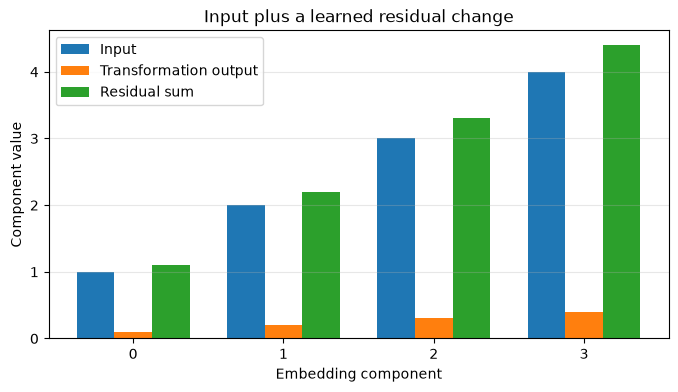

In [3]:
import matplotlib.pyplot as plt

component_positions = torch.arange(embedding_dimension).tolist()
bar_width = 0.25

plt.figure(figsize=(8, 4))
plt.bar(
    [position - bar_width for position in component_positions],
    input_vectors[0, 0].detach().tolist(),
    width=bar_width,
    label="Input",
)
plt.bar(
    component_positions,
    transformation_output[0, 0].detach().tolist(),
    width=bar_width,
    label="Transformation output",
)
plt.bar(
    [position + bar_width for position in component_positions],
    residual_output[0, 0].detach().tolist(),
    width=bar_width,
    label="Residual sum",
)
plt.xticks(component_positions)
plt.xlabel("Embedding component")
plt.ylabel("Component value")
plt.title("Input plus a learned residual change")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.show()

The residual sum includes the full input value plus the branch's change for each component.


## Exact shape equality is the transformer invariant

PyTorch permits some additions through broadcasting, but silent broadcasting is not the intended transformer residual operation.

A transformer residual branch should return exactly the same `[B, T, C]` shape as its skip branch.

Exact equality prevents a missing batch, context, or feature axis from being repeated accidentally.


In [4]:
def add_residual(
    skip_values: torch.Tensor,
    residual_values: torch.Tensor,
) -> torch.Tensor:
    if residual_values.shape != skip_values.shape:
        raise ValueError(
            "residual and skip tensors must have exactly the same shape; "
            f"got {tuple(skip_values.shape)} and {tuple(residual_values.shape)}."
        )

    return skip_values + residual_values


helper_output = add_residual(input_vectors, transformation_output)
wrong_width_transformation = torch.nn.Linear(
    embedding_dimension, embedding_dimension - 1
).to(device)
wrong_width_output = wrong_width_transformation(input_vectors)
broadcastable_but_wrong = transformation_output[:1]

print("helper matches direct addition:", torch.allclose(helper_output, residual_output))
print("wrong-width output shape:", wrong_width_output.shape)
print(
    "wrong-width shape matches exactly:",
    wrong_width_output.shape == input_vectors.shape,
)
print("broadcastable tensor shape:", broadcastable_but_wrong.shape)
print(
    "broadcastable shape matches exactly:",
    broadcastable_but_wrong.shape == input_vectors.shape,
)

helper matches direct addition: True
wrong-width output shape: torch.Size([2, 2, 3])
wrong-width shape matches exactly: False
broadcastable tensor shape: torch.Size([1, 2, 4])
broadcastable shape matches exactly: False


The width-`3` branch cannot be added component by component to width `4`.

The `[1, 2, 4]` branch could broadcast across a batch of size `2`, but doing so would reuse one example's residual for another example.

The helper rejects both cases through one exact-shape contract.


## An easy identity path

If the residual branch returns zero, the block returns its input exactly.

This gives a shape-preserving residual block a simple identity behavior without requiring the transformation to learn an identity mapping internally.


In [5]:
zero_change = torch.zeros_like(input_vectors)
small_change = 0.01 * torch.ones_like(input_vectors)
identity_result = add_residual(input_vectors, zero_change)
small_change_result = add_residual(input_vectors, small_change)

print("zero branch preserves input:", torch.equal(identity_result, input_vectors))
print("selected input:", input_vectors[0, 0])
print("selected zero-branch result:", identity_result[0, 0])
print("selected small-change result:", small_change_result[0, 0])

zero branch preserves input: True
selected input: tensor([1., 2., 3., 4.])
selected zero-branch result: tensor([1., 2., 3., 4.])
selected small-change result: tensor([1.0100, 2.0100, 3.0100, 4.0100])


The identity option does not force every learned branch to stay small or make every deep model stable automatically.

It provides a direct route for existing representations when a transformation contributes little.


## The skip branch also carries gradients

Backpropagation through `input + transformation(input)` includes a direct contribution from the input term.

We can observe that path without introducing calculus notation.

A zero linear transformation produces zero input gradients by itself, while adding the skip branch produces unit input gradients for a summed output.


In [6]:
zero_linear = torch.nn.Linear(3, 3, bias=False).to(device)
with torch.no_grad():
    zero_linear.weight.zero_()

plain_input = torch.tensor([[1.0, 2.0, 3.0]], device=device, requires_grad=True)
plain_output = zero_linear(plain_input).sum()
plain_gradient = torch.autograd.grad(plain_output, plain_input)[0]

residual_input = torch.tensor([[1.0, 2.0, 3.0]], device=device, requires_grad=True)
residual_sum = (residual_input + zero_linear(residual_input)).sum()
residual_gradient = torch.autograd.grad(residual_sum, residual_input)[0]

print("gradient through zero transformation alone:", plain_gradient)
print("gradient through zero transformation plus skip:", residual_gradient)

gradient through zero transformation alone: tensor([[0., 0., 0.]])
gradient through zero transformation plus skip: tensor([[1., 1., 1.]])


The direct path carries gradient even when the residual branch contributes none.

This improved gradient flow is a major reason residual connections help optimization in deep networks.

Residual connections support deep training but do not by themselves guarantee well-conditioned activations or successful optimization.


## Residual attention needs width `C`

Chapter 62 concatenated multi-head features and projected them back to embedding width `C`.

That final projection makes the attention output shape match its `[B, T, C]` input.

The compact causal attention module below uses one width-`C` head and a width-`C` output projection to demonstrate the same residual requirement without repeating the multi-head implementation.


In [7]:
import math


class ShapePreservingCausalSelfAttention(torch.nn.Module):
    embedding_dimension: int
    maximum_context_length: int
    query_projection: torch.nn.Linear
    key_projection: torch.nn.Linear
    value_projection: torch.nn.Linear
    output_projection: torch.nn.Linear
    causal_mask: torch.Tensor

    def __init__(self, embedding_dimension: int, maximum_context_length: int) -> None:
        super().__init__()

        if embedding_dimension < 1 or maximum_context_length < 1:
            raise ValueError("dimensions must be positive.")

        self.embedding_dimension = embedding_dimension
        self.maximum_context_length = maximum_context_length
        self.query_projection = torch.nn.Linear(
            embedding_dimension, embedding_dimension, bias=False
        )
        self.key_projection = torch.nn.Linear(
            embedding_dimension, embedding_dimension, bias=False
        )
        self.value_projection = torch.nn.Linear(
            embedding_dimension, embedding_dimension, bias=False
        )
        self.output_projection = torch.nn.Linear(
            embedding_dimension, embedding_dimension
        )
        self.register_buffer(
            "causal_mask",
            torch.tril(
                torch.ones(
                    1,
                    maximum_context_length,
                    maximum_context_length,
                    dtype=torch.bool,
                )
            ),
        )

    def forward(self, input_vectors: torch.Tensor) -> torch.Tensor:
        if input_vectors.ndim != 3:
            raise ValueError("input must have shape [batch, context, embedding].")

        if input_vectors.shape[-1] != self.embedding_dimension:
            raise ValueError("input embedding dimension is incorrect.")

        current_context_length = input_vectors.shape[-2]
        if current_context_length > self.maximum_context_length:
            raise ValueError("input exceeds the maximum context length.")

        queries = self.query_projection(input_vectors)
        keys = self.key_projection(input_vectors)
        values = self.value_projection(input_vectors)
        scores = queries @ keys.transpose(-2, -1)
        scores = scores / math.sqrt(self.embedding_dimension)
        allowed = self.causal_mask[:, :current_context_length, :current_context_length]
        weights = torch.softmax(scores.masked_fill(~allowed, float("-inf")), dim=-1)
        attention_values = weights @ values
        return self.output_projection(attention_values)


torch.manual_seed(64)
batch_size = 2
context_length = 4
attention_embedding_dimension = 8
attention_input = torch.randn(
    batch_size, context_length, attention_embedding_dimension, device=device
)
attention_module = ShapePreservingCausalSelfAttention(
    embedding_dimension=attention_embedding_dimension,
    maximum_context_length=context_length,
).to(device)
attention_change = attention_module(attention_input)
values_after_attention = add_residual(attention_input, attention_change)

print("attention input shape:", attention_input.shape)
print("attention change shape:", attention_change.shape)
print("residual result shape:", values_after_attention.shape)

attention input shape: torch.Size([2, 4, 8])
attention change shape: torch.Size([2, 4, 8])
residual result shape: torch.Size([2, 4, 8])


The attention branch and skip branch both have shape `[2, 4, 8]`.

Attention mixes information across allowed context positions, while the residual addition operates elementwise on corresponding `[batch, position, feature]` entries.


The selected-vector trace prints the skip value, attention change, and residual sum component by component.


In [8]:
selected_batch = 0
selected_position = 2

print("component | skip value | attention change | residual sum")
print("-" * 62)
for component in range(attention_embedding_dimension):
    skip_value = attention_input[selected_batch, selected_position, component].item()
    change_value = attention_change[selected_batch, selected_position, component].item()
    result_value = values_after_attention[
        selected_batch, selected_position, component
    ].item()
    print(
        f"{component:>9} | {skip_value:>10.4f} | "
        f"{change_value:>16.4f} | {result_value:>12.4f}"
    )

print(
    "selected vector addition is correct:",
    torch.allclose(
        values_after_attention[selected_batch, selected_position],
        attention_input[selected_batch, selected_position]
        + attention_change[selected_batch, selected_position],
    ),
)

component | skip value | attention change | residual sum
--------------------------------------------------------------
        0 |     2.0451 |           0.4900 |       2.5351
        1 |    -1.9229 |          -0.1943 |      -2.1172
        2 |     0.9288 |           0.0573 |       0.9861
        3 |    -1.0458 |          -0.2775 |      -1.3233
        4 |    -0.0137 |          -0.0272 |      -0.0409
        5 |    -0.5181 |          -0.1553 |      -0.6735
        6 |    -0.7992 |          -0.4329 |      -1.2321
        7 |     1.7186 |          -0.4808 |       1.2378
selected vector addition is correct: True


Every displayed residual component equals the corresponding skip component plus attention component.


## A reusable residual wrapper

A wrapper can add a skip connection around any module that obeys the exact shape contract.

The skip branch has no parameters of its own, but both values and gradients travel through it.


In [9]:
class ResidualConnection(torch.nn.Module):
    transformation: torch.nn.Module

    def __init__(self, transformation: torch.nn.Module) -> None:
        super().__init__()
        self.transformation = transformation

    def forward_with_change(
        self, input_values: torch.Tensor
    ) -> tuple[torch.Tensor, torch.Tensor]:
        transformation_output = self.transformation(input_values)
        output_values = add_residual(input_values, transformation_output)
        return output_values, transformation_output

    def forward(self, input_values: torch.Tensor) -> torch.Tensor:
        output_values, _ = self.forward_with_change(input_values)
        return output_values


residual_attention = ResidualConnection(attention_module)
wrapped_output, wrapped_change = residual_attention.forward_with_change(attention_input)

print("wrapped output shape:", wrapped_output.shape)
print("wrapped change shape:", wrapped_change.shape)
print(
    "wrapper matches direct residual:",
    torch.allclose(wrapped_output, values_after_attention),
)
print(
    "wrapper parameters come from transformation:",
    len(list(residual_attention.parameters()))
    == len(list(attention_module.parameters())),
)

wrapped output shape: torch.Size([2, 4, 8])
wrapped change shape: torch.Size([2, 4, 8])
wrapper matches direct residual: True
wrapper parameters come from transformation: True


The wrapper adds no trainable skip-path parameters and exactly reproduces the direct attention residual.

The same wrapper pattern can surround other shape-preserving transformer sublayers.


## Why shape preservation supports depth

A transformer block conventionally receives and returns `[B, T, C]`.

That stable contract allows one block's output to become the next block's input and permits residual addition inside every block.

Residual connections provide an identity route for representations and gradients while learned branches refine those representations.

They are one part of deep transformer optimization rather than a complete solution by themselves.


## Common mistakes

- **Replacing instead of adding:** a residual block returns `input + transformation(input)`.

- **Accepting accidental broadcasting:** transformer skip and residual tensors should have exactly equal shapes.

- **Dropping the attention output projection:** attention must return to width `C` before addition to a width-`C` input.

- **Calling the skip branch inactive:** it has no parameters, but values and gradients flow through it.

- **Assuming the learned change is always small:** residual branches can learn changes of any magnitude.

- **Assuming residuals guarantee stable training:** they improve information and gradient paths but work with other architectural and optimization choices.

- **Collapsing sequence shape:** residual attention preserves batch, context, and embedding axes.


## Takeaways

- A residual connection adds a transformation output to the original input.

- The skip branch carries the input directly around the transformation.

- A zero residual branch gives an exact identity mapping.

- The skip branch provides a direct gradient path during backpropagation.

- Transformer residual addition expects exact `[B, T, C]` shape equality.

- Attention's output projection restores embedding width `C` for residual compatibility.

- A reusable wrapper can add a residual connection around any shape-preserving module.

> Residual branches learn changes while skip branches preserve a direct route through the network.


## What comes next

Residual connections provide direct paths for representations and gradients.

The next chapter introduces layer normalization, which controls each position's feature statistics and must be placed carefully relative to residual branches.
